<a href="https://colab.research.google.com/github/claire-mansfield/PHSXlab/blob/main/Damped_oscillator_Claire_mansfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

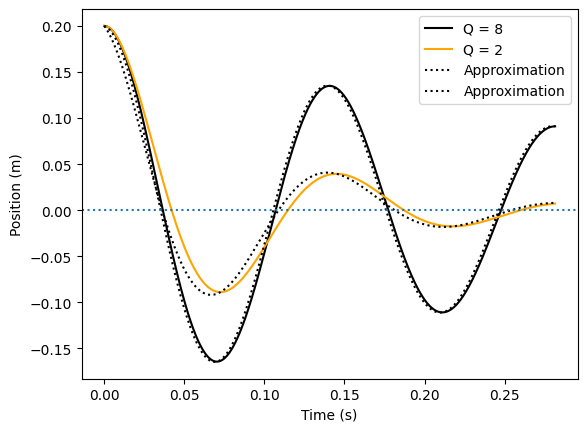

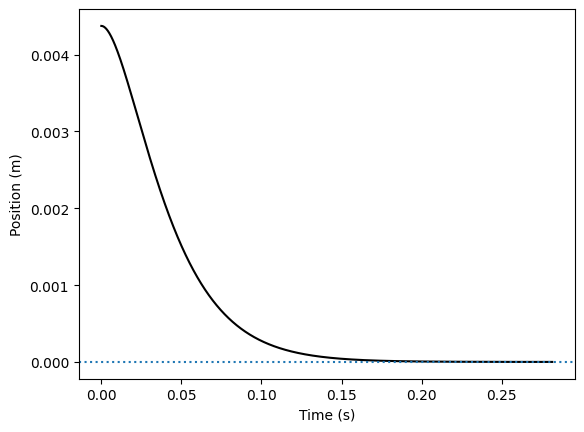

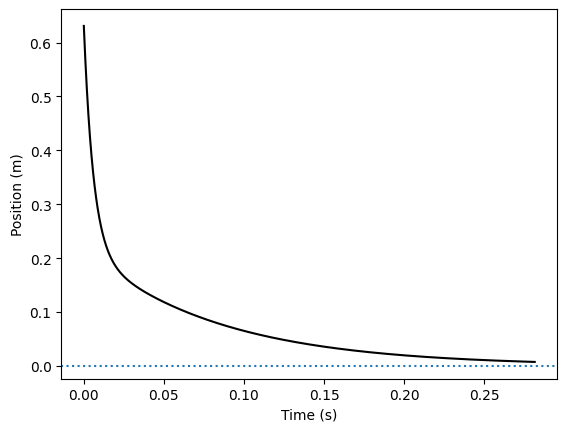

In [8]:
import numpy as np
from numpy import arctan2
from matplotlib import pylab as plt

A_0 = 0.200
k = 2.5 * 10**2
m = 0.125
Q_ud = np.array([8,2])
Q_cd = 1/2
#Q_od

#calculate natural angular frequency
w0 = (k/m) ** (1/2)

#underdamped constant calculations

gamma_ud = np.array([w0/q for q in Q_ud])
omega_ud = np.array([(w0 ** 2 - (g/2) ** 2) ** (1/2) for g in gamma_ud])
P_ud = np.array([2 * np.pi / o for o in omega_ud ])
phi_ud = np.array(arctan2([-g for g in gamma_ud], [2*o for o in omega_ud]))
A_ud = np.array([A_0 * w0 / w for w in omega_ud])

#critically damped
gamma_cd = w0 / Q_cd

omega_cd = (w0 ** 2 - (gamma_cd / 2) ** 2) ** (1/2)


C1 = 2 * A_0 / (2 + gamma_cd)
C2 = A_0 - (2 * A_0 /(2 + gamma_cd))





#overdamped
Q_od = 0.25
gamma_od = w0 / Q_od
p1 = (-gamma_od + np.sqrt(gamma_od**2 - 4*w0**2)) / 2
p2 = (-gamma_od - np.sqrt(gamma_od**2 - 4*w0**2)) / 2

C1_o = -A_0 * p2 / (p1 - p2)
C2_o = A_0 - (A_0 * p2)/(p1 - p2)



#time settings for plot
tmin = 0
tmax = 2 * np.min([P_ud])
nstep = 5000

t = np.linspace(tmin, tmax, nstep)


#set up time array
t = np.linspace(tmin, tmax, nstep)

#oscillator eqns underdamped

x_8 = A_ud[0] * np.exp((-gamma_ud[0] / 2) * t) * np.cos(omega_ud[0] * t + phi_ud[0])
x_2 = A_ud[1] * np.exp((-gamma_ud[1] / 2) * t) * np.cos(omega_ud[1] * t + phi_ud[1])

#approx

x_8_approx = A_0 * np.exp((-gamma_ud[0] / 2) * t) * np.cos(omega_ud[0] * t )
x_2_approx = A_0 * np.exp((-gamma_ud[1] / 2) * t) * np.cos(omega_ud[1] * t )


x_od = C1_o * np.exp((p1 * t)) + C2_o * np.exp((p2 * t))

x_crit = C1 * np.exp((-gamma_cd/2) * t) + C2 * t * np.exp((-gamma_cd/2) * t)



plt.plot(t, x_8, linestyle = '-', color = 'black', label = 'Q = ' + str(Q_ud[0]))
plt.plot(t, x_2, linestyle = '-', color = 'orange', label = 'Q = ' + str(Q_ud[1]))
plt.plot(t, x_8_approx, color = 'black', label = 'Approximation', linestyle = ':')
plt.plot(t, x_2_approx, color = 'black', label = 'Approximation', linestyle = ':')
plt.axhline(y=0, linestyle = ':')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.show()



plt.plot(t, x_crit, color = 'black')
plt.axhline(y=0, linestyle = ':')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.show()

plt.plot(t, x_od, color = 'black')
plt.axhline(y=0, linestyle = ':')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.show()


In [10]:
m = 0.250
k = 6400
percent_decrease = 15.0
time = 5*60
w0 = np.sqrt(k/m)
print("W0 =", w0)

#A(t) = A0 exp[-gamma * t / 2]
#A(t)= 0.85*A0

A_ratio = 0.85
gamma = -2 * np.log(A_ratio) / time

Q = w0/gamma

print("gamma = ", gamma)
print("Q=", Q)

energy_fraction = A_ratio**2
energy_lost_percent = (1-energy_fraction) * 100
print("Energy remaining =", energy_fraction*100, "%")
print("Energy converted=", energy_lost_percent, "%")




W0 = 160.0
gamma =  0.0010834595299851662
Q= 147675.10513492883
Energy remaining = 72.24999999999999 %
Energy converted= 27.750000000000007 %
